<div style="
    background-color: #0b2343; 
    color: white; 
    padding: 25px; 
    font-family: Arial, sans-serif;
">
    <h2 style="margin: 0; font-size: 24px; font-weight: normal;">
        Data Analytics & Machine Learning in Finance
    </h2>
    <h1 style="margin: 5px 0 0 0; font-size: 48px; font-weight: bold;">
        Classification (Random Forest, Gradient Boosting)
    </h1>
    <div style="display: flex; justify-content: space-between; margin-top: 20px;">
        <div style="text-align: left;">
            <p style="margin: 8px 0 0 0; font-size: 18px;">
                Pedro Ramón Ventura Gómez
            </p>
            <p style="margin: 2px 0 0 0; font-size: 16px;">
                pventura@march-am.com
            </p>
        </div>
        <div style="text-align: right;">
            <p style="margin: 8px 50px 0 0; font-size: 18px;">
                Pablo Hernández Cámara
            </p>
            <p style="margin: 2px 50px 0 0; font-size: 16px;">
                pablo.hernandez-camara@uv.es
            </p>
        </div>
    </div>
</div>


# Classification (Random Forest, Gradient Boosting)

## Random Forest


**Random Forest** is a **supervised ensemble learning algorithm** used for **classification** (and regression) tasks.

It builds a collection (*forest*) of **parallel** decision trees and combines their outputs to make more robust predictions.

* **Supervised:** Requires a labeled dataset (features $X$ and target $y$) to learn.
* **Classification:** Predicts the class of a new sample by aggregating the predictions of many decision trees (majority vote).
* **Ensemble method:** Combines multiple weak learners (individual trees) to create a stronger model.
* **Non-parametric:** Does not assume a specific distribution or fixed functional form.


### How it works

1. **Bootstrap sampling (Bagging):** Each tree is trained on a random **sample with replacement** of the training data. This ensures that every tree sees a slightly different dataset, introducing **diversity** into the forest.

2. **Random feature selection:** At each split (at each node), only a random subset of features is considered. This further **decorrelates** the trees, so they do not all make the same decisions.

3. **Tree growing:** Each tree is usually grown to maximum depth (unpruned). Instead of pruning to prevent overfitting, Random Forest relies on **randomness + majority vote (average)** to reduce variance.
   - This makes some trees perform well on certain subsets of data and poorly on others.
   - The key idea: **individual trees may be weak, but the ensemble is strong**.

4. **Aggregation:**
   - **Classification:** Each tree votes for a class, and the forest prediction is the **majority vote**.
   - **Regression:** Each tree outputs a value, and the forest prediction is the **average** of those values.

<div style="text-align: center">
    <img src="./images/classification/random_forest.webp" style="width:75%;background-color: white; padding: 10px;">
</div>

### Main Hyperparameters

- Number of trees in the forest.
- Number of features considered at each split.
- Maximum tree depth, minimum samples per split/leaf (to control complexity).

### Advantages

- **High accuracy:** Reduces variance by averaging many trees.
- **Works with both categorical and numerical data.**
- **Feature importance:** Can estimate which features are most influential.
- **Non-parametric:** No assumption about data distribution.
- **Fast inference:** Trees run in parallel.

### Disadvantages

- **Less interpretable:** Harder to visualize than a single tree.
- **Large memory usage:** Storing many trees can be costly.
- **Overfitting risk:** Even though Random Forests are generally robust, they can overfit when the **feature space is small** and you use **too many estimators**.
  * Random Forests shine in *high-dimensional* settings (lots of features), where random feature selection adds diversity.
  * With a **small number of features**, trees tend to look very similar, so adding more estimators mostly reinforces the same splits instead of adding diversity.
  * With a **small number of samples**, you should also control tree complexity (e.g., by limiting depth, setting minimum samples per leaf/split). This acts as a form of *pre-pruning* to avoid overly complex trees that memorize noise.

## Playing with financial assets: Stock Picking

Lets recall the linear regression example, where we achieved an accuracy of 51.25% and a final accumulated return of the portfolio of 30.16%

In [2]:
import numpy as np
import pandas as pd

Load data

In [3]:
train_df = pd.read_csv("../dataset/01_LR_training_data_standardized.csv")
predict_df = pd.read_csv("../dataset/01_LR_prediction_data_standardized.csv")
test_px_comp = pd.read_csv("../dataset/01_LR_test_data_component_prices.csv", index_col="Date", parse_dates=True)
test_px_idx = pd.read_csv("../dataset/01_LR_test_data_index_prices.csv", index_col="Date", parse_dates=True)

In [4]:
train_df.shape

(42536, 7)

Train model

In [5]:
from sklearn.ensemble import RandomForestClassifier

X = train_df.iloc[:, :-1]
y = train_df["target"]

model_rfc = RandomForestClassifier(n_estimators=3, bootstrap=True, random_state=42)
model_rfc.fit(X, y)

print(f"Accuracy: {model_rfc.score(X, y)}")


Accuracy: 0.9109460221929659


Predict probabilities of out- or underperform for the next week (class 1 or 0).

In [6]:
# Predict probabilities of out- or underperform for the next week (class 1 or 0).
proba_next_test = model_rfc.predict_proba(predict_df.iloc[:, 1:])
# Create a DataFrame with the results, add tickers and sort descending.
df = pd.DataFrame(proba_next_test, columns=["P(y=0)", "P(y=1)"])
df["ticker"] = predict_df["ticker"].values
df.set_index("ticker", inplace=True)
df.sort_values(by="P(y=1)", ascending=False, inplace=True)
# Select those with a probability greater than 'th'.
th = 0.8
df_top_n = df[df["P(y=1)"] > th]
# Create a portfolio using probabilities as weights.
portfolio_weights = df_top_n.loc[:, ["P(y=1)"]] / df_top_n.loc[:, ["P(y=1)"]].sum()
portfolio_weights.columns = ["weight"]
portfolio_weights


,weight
ticker,
BA,0.018182
VZ,0.018182
SBAC,0.018182
CME,0.018182
AME,0.018182
AMP,0.018182
BAX,0.018182
SYK,0.018182
CF,0.018182


In [7]:
# Log returns for components and index.
ret_comp = np.log(test_px_comp).diff().fillna(0)
ret_idx = np.log(test_px_idx).diff().fillna(0)
# Log returns for the portfolio.
print(f"Shape of portfolio weights: {portfolio_weights['weight'].shape}")
print(f"Shape of component returns: {ret_comp.loc[:, portfolio_weights.index].shape}")
ret_p = ret_comp.loc[:, portfolio_weights.index] @ portfolio_weights["weight"]  # R @ w
ret_p.name = "Portfolio"
ret_p

Shape of portfolio weights: (55,)
Shape of component returns: (52, 55)


Date
2009-12-30    0.000000
2010-01-06    0.013013
2010-01-13    0.013991
2010-01-20   -0.012863
2010-01-27   -0.040729
2010-02-03   -0.003632
2010-02-10   -0.029359
2010-02-17    0.043698
2010-02-24    0.005204
2010-03-03    0.028133
2010-03-10    0.026358
2010-03-17    0.023826
2010-03-24    0.007679
2010-03-31   -0.001025
2010-04-07    0.019050
2010-04-14    0.022978
2010-04-21    0.003300
2010-04-28   -0.003945
2010-05-05   -0.022392
2010-05-12    0.014835
2010-05-19   -0.057973
2010-05-26   -0.040271
2010-06-02    0.028573
2010-06-09   -0.051048
2010-06-16    0.072466
2010-06-23   -0.026612
2010-06-30   -0.065188
2010-07-07    0.022174
2010-07-14    0.042545
2010-07-21   -0.026986
2010-07-28    0.048156
2010-08-04    0.030868
2010-08-11   -0.042649
2010-08-18    0.011679
2010-08-25   -0.037939
2010-09-01    0.034039
2010-09-08    0.023058
2010-09-15    0.025695
2010-09-22    0.007619
2010-09-29    0.019321
2010-10-06    0.013262
2010-10-13    0.022610
2010-10-20    0.000075
2010-1

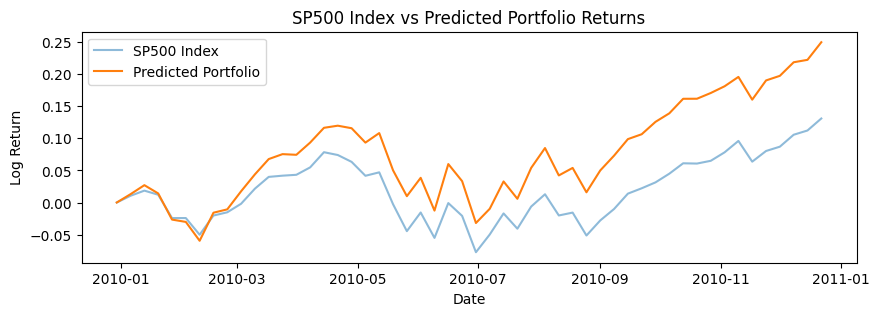

Final accumulated return of SP500 Index: 0.13084380194114686
Final accumulated return of Predicted Portfolio: 0.2495988629887002


In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 3))
plt.plot(ret_idx.cumsum(), label="SP500 Index", alpha=0.5)
plt.plot(ret_p.cumsum(), label="Predicted Portfolio")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.title("SP500 Index vs Predicted Portfolio Returns")
plt.legend()
plt.show()

print(f"Final accumulated return of SP500 Index: {ret_idx.cumsum().iloc[-1, 0]}")
print(f"Final accumulated return of Predicted Portfolio: {ret_p.cumsum().iloc[-1]}")


**Homework**

- Complete the backtest of the strategy by iterating through the remaining train/test datasets.
- Try to improve the model's accuracy by incorporating additional features (take the paper as a reference).
- Play with hyper-parameters (parameters of the `RandomForestClassifier` class).

Resumen de backtest (iterando datasets):


,dataset,n_selected,train_acc,best_params,final_ret_portfolio,final_ret_index,alpha_vs_index
0,01,10,1.0,"{'n_estimators': 250, 'max_depth': None, 'min_...",0.176943,0.130844,0.046099


Promedio alpha vs índice: 0.04609891840553995


C:\Users\oscar\AppData\Local\Temp\ipykernel_7276\3551396274.py:162: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


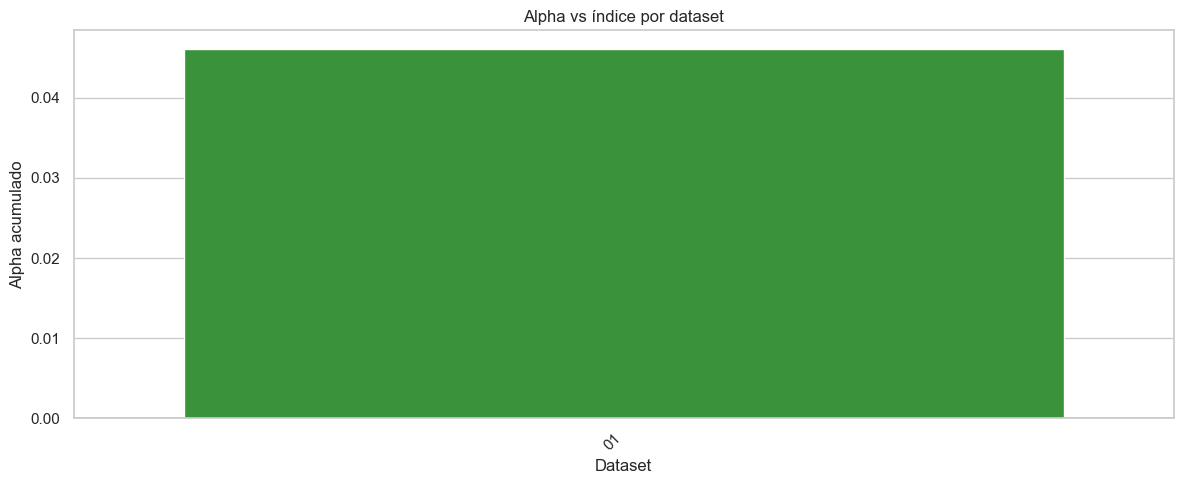

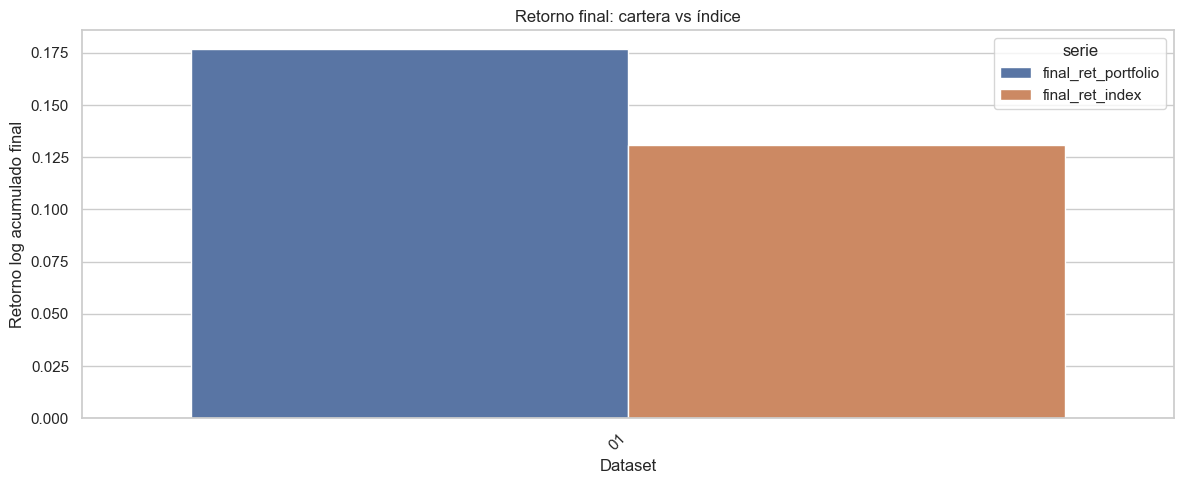

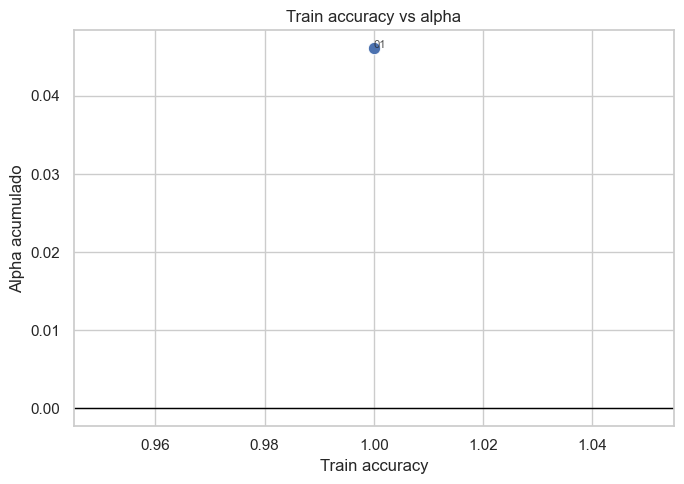

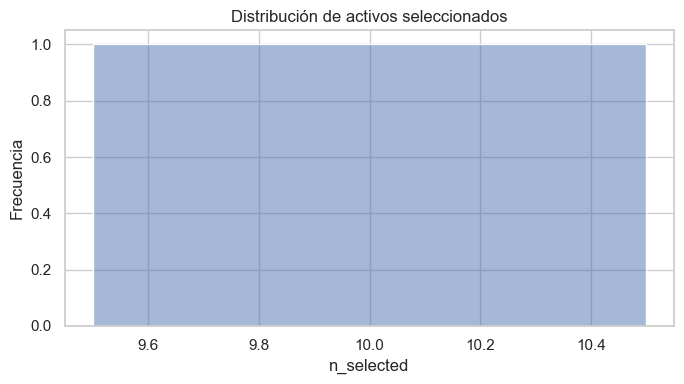

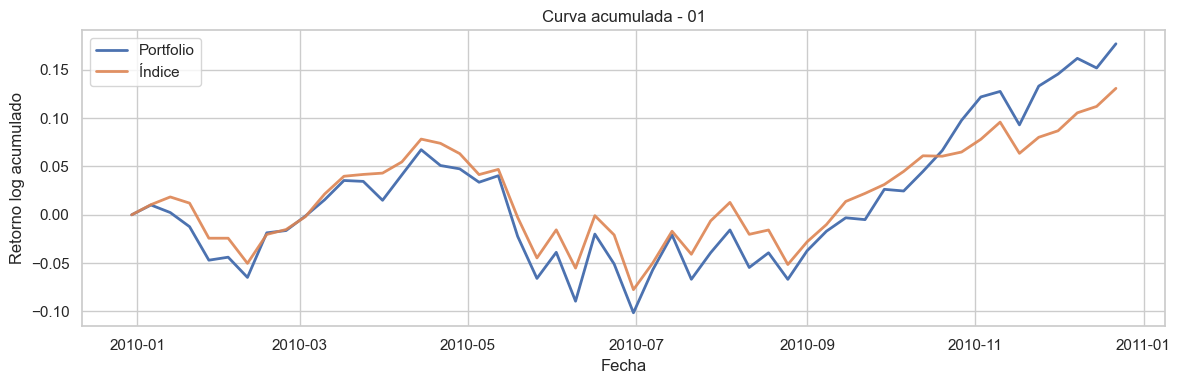

In [11]:
# Homework solution: iterate train/test sets, add simple features, tune RF hyperparameters
# + visualizaciones de resultados.

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier

# Estilo de gráficos
sns.set(style="whitegrid", context="notebook")

base = Path("../dataset")
train_files = sorted(base.glob("*_LR_training_data_standardized.csv"))

def add_simple_features(df_features: pd.DataFrame) -> pd.DataFrame:
    """Small, generic feature expansion to test if accuracy improves."""
    out = df_features.copy()
    out["feat_mean"] = out.mean(axis=1)
    out["feat_std"] = out.std(axis=1)
    out["feat_abs_mean"] = out.abs().mean(axis=1)
    return out


param_grid = [
    {"n_estimators": 50, "max_depth": 4, "min_samples_leaf": 3, "max_features": "sqrt"},
    {"n_estimators": 120, "max_depth": 6, "min_samples_leaf": 2, "max_features": "sqrt"},
    {"n_estimators": 250, "max_depth": None, "min_samples_leaf": 1, "max_features": "sqrt"},
]

results = []
curves = {}  # guardamos curvas acumuladas por dataset para visualización

for train_file in train_files:
    prefix = train_file.name.split("_LR_training_data_standardized.csv")[0]
    pred_file = base / f"{prefix}_LR_prediction_data_standardized.csv"
    comp_file = base / f"{prefix}_LR_test_data_component_prices.csv"
    idx_file = base / f"{prefix}_LR_test_data_index_prices.csv"

    # Skip incomplete sets
    if not (pred_file.exists() and comp_file.exists() and idx_file.exists()):
        print(f"[skip] Dataset {prefix}: faltan archivos complementarios.")
        continue

    train_df = pd.read_csv(train_file)
    predict_df = pd.read_csv(pred_file)
    test_px_comp = pd.read_csv(comp_file, index_col="Date", parse_dates=True)
    test_px_idx = pd.read_csv(idx_file, index_col="Date", parse_dates=True)

    if "target" not in train_df.columns:
        print(f"[skip] Dataset {prefix}: no existe columna 'target'.")
        continue

    X_train = train_df.drop(columns=["target"])
    y_train = train_df["target"]

    # Keep ticker aside if present in prediction file
    ticker_col = "ticker" if "ticker" in predict_df.columns else None
    X_pred_raw = predict_df.drop(columns=[ticker_col]) if ticker_col else predict_df.copy()

    X_train_ext = add_simple_features(X_train)
    X_pred_ext = add_simple_features(X_pred_raw)

    # Align columns in case train/predict differ slightly
    X_pred_ext = X_pred_ext.reindex(columns=X_train_ext.columns, fill_value=0)

    best_model = None
    best_acc = -np.inf
    best_params = None

    # Selección simple de hiperparámetros por accuracy in-sample (tal como en tu código)
    for params in param_grid:
        model = RandomForestClassifier(
            random_state=42,
            bootstrap=True,
            **params,
        )
        model.fit(X_train_ext, y_train)
        acc = model.score(X_train_ext, y_train)
        if acc > best_acc:
            best_acc = acc
            best_model = model
            best_params = params

    proba = best_model.predict_proba(X_pred_ext)
    prob_df = pd.DataFrame(proba, columns=["P(y=0)", "P(y=1)"])

    if ticker_col:
        prob_df["ticker"] = predict_df[ticker_col].values
    else:
        prob_df["ticker"] = np.arange(len(prob_df)).astype(str)

    prob_df = prob_df.set_index("ticker").sort_values("P(y=1)", ascending=False)

    # Portfolio rule: threshold + fallback to top 10 if empty
    th = 0.8
    selected = prob_df[prob_df["P(y=1)"] > th]
    if selected.empty:
        selected = prob_df.head(10)

    weights = selected[["P(y=1)"]] / selected[["P(y=1)"]].sum()
    weights.columns = ["weight"]

    # Keep only tickers that exist in component prices
    valid_tickers = [t for t in weights.index if t in test_px_comp.columns]
    if not valid_tickers:
        print(f"[skip] Dataset {prefix}: no hay tickers en común con precios de test.")
        continue

    weights = weights.loc[valid_tickers]

    ret_comp = np.log(test_px_comp).diff().fillna(0)
    ret_idx = np.log(test_px_idx).diff().fillna(0)

    # Retornos diarios
    ret_p = ret_comp.loc[:, weights.index] @ weights["weight"]
    ret_i = ret_idx.iloc[:, 0]

    # Curvas acumuladas
    cum_p = ret_p.cumsum()
    cum_i = ret_i.cumsum()

    final_portfolio = float(cum_p.iloc[-1])
    final_index = float(cum_i.iloc[-1])

    curves[prefix] = pd.DataFrame(
        {"portfolio_cumret": cum_p, "index_cumret": cum_i}
    )

    results.append(
        {
            "dataset": prefix,
            "n_selected": int(len(weights)),
            "train_acc": float(best_acc),
            "best_params": str(best_params),
            "final_ret_portfolio": final_portfolio,
            "final_ret_index": final_index,
            "alpha_vs_index": final_portfolio - final_index,
        }
    )

results_df = pd.DataFrame(results)

if results_df.empty:
    print("No hay resultados para mostrar.")
else:
    results_df = results_df.sort_values("alpha_vs_index", ascending=False).reset_index(drop=True)

    print("Resumen de backtest (iterando datasets):")
    display(results_df)

    print("Promedio alpha vs índice:", results_df["alpha_vs_index"].mean())

    # =========================
    # VISUALIZACIONES
    # =========================

    # 1) Barras de alpha por dataset
    plt.figure(figsize=(12, 5))
    sns.barplot(
        data=results_df,
        x="dataset",
        y="alpha_vs_index",
        palette=["#2ca02c" if v >= 0 else "#d62728" for v in results_df["alpha_vs_index"]],
    )
    plt.axhline(0, color="black", linewidth=1)
    plt.title("Alpha vs índice por dataset")
    plt.xlabel("Dataset")
    plt.ylabel("Alpha acumulado")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    # 2) Portfolio vs índice (retorno final) por dataset
    melted = results_df.melt(
        id_vars=["dataset"],
        value_vars=["final_ret_portfolio", "final_ret_index"],
        var_name="serie",
        value_name="retorno_final"
    )

    plt.figure(figsize=(12, 5))
    sns.barplot(data=melted, x="dataset", y="retorno_final", hue="serie")
    plt.title("Retorno final: cartera vs índice")
    plt.xlabel("Dataset")
    plt.ylabel("Retorno log acumulado final")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    # 3) Relación accuracy train vs alpha (control visual de sobreajuste)
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=results_df, x="train_acc", y="alpha_vs_index", s=80)
    for _, row in results_df.iterrows():
        plt.text(row["train_acc"], row["alpha_vs_index"], row["dataset"], fontsize=8, alpha=0.8)
    plt.axhline(0, color="black", linewidth=1)
    plt.title("Train accuracy vs alpha")
    plt.xlabel("Train accuracy")
    plt.ylabel("Alpha acumulado")
    plt.tight_layout()
    plt.show()

    # 4) Distribución del número de activos seleccionados
    plt.figure(figsize=(7, 4))
    sns.histplot(results_df["n_selected"], bins=min(10, results_df["n_selected"].nunique()), kde=True)
    plt.title("Distribución de activos seleccionados")
    plt.xlabel("n_selected")
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

    # 5) Curvas acumuladas para top 3 datasets por alpha
    top_datasets = results_df.head(3)["dataset"].tolist()
    if top_datasets:
        fig, axes = plt.subplots(len(top_datasets), 1, figsize=(12, 4 * len(top_datasets)), sharex=False)
        if len(top_datasets) == 1:
            axes = [axes]

        for ax, ds in zip(axes, top_datasets):
            cdf = curves.get(ds)
            if cdf is None or cdf.empty:
                continue
            ax.plot(cdf.index, cdf["portfolio_cumret"], label="Portfolio", linewidth=2)
            ax.plot(cdf.index, cdf["index_cumret"], label="Índice", linewidth=2, alpha=0.9)
            ax.set_title(f"Curva acumulada - {ds}")
            ax.set_ylabel("Retorno log acumulado")
            ax.legend()

        plt.xlabel("Fecha")
        plt.tight_layout()
        plt.show()

## Gradient Boosting

**Gradient Tree Boosting** is a **supervised ensemble learning algorithm** used for **classification** (and regression).

It builds a strong predictive model by combining many **weak learners** (usually shallow decision trees) in a **sequential** manner, where each new tree corrects the errors of the previous ones.

- **Supervised:** Requires a labeled dataset (features $X$ and target $y$).
- **Classification:** Predicts the class of a new sample by iteratively improving probability estimates.
- **Ensemble method (Boosting):** Combines weak learners sequentially, each focused on reducing the mistakes of the ensemble so far.
- **Non-parametric:** Makes no assumptions about data distribution.

### How it works
1. **Initialize the model:**
   Start with a constant prediction (e.g., log-odds of the positive class).

   - Probability ($p$): This is the likelihood that an instance belongs to the positive class. 
   - Odds: The odds are the ratio of the probability of success to the probability of failure (the negative class).
      $$Odds = p / (1-p)$$
   - Log-Odds (Logit): The natural logarithm of the odds gives the log-odds. 
      $$log(p / (1-p))$$

2. **Compute residuals (pseudo-residuals):**
   For each sample, compute how far the current prediction is from the true label.

   - In classification, this is the **negative gradient of the loss function** (e.g., cross-entropy).

      $$
      XE(y, \hat{y}) = - \Big[ y \log(\hat{y}) + (1-y)\log(1-\hat{y}) \Big]
      $$

3. **Fit a weak learner:**
   Train a shallow decision tree to predict these residuals.

4. **Update the model:**
   Add the new tree to the ensemble, weighted by a learning rate $\eta$:

   $$
   F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)
   $$

   - $F_m(x)$: prediction after $m$ trees
   - $h_m(x)$: prediction from the new tree

5. **Repeat:**
   Iterate steps 2–4 for a set number of trees (estimators) or until convergence.

6. **Final prediction:**

   - **Classification:** Transform the final score into probabilities via the sigmoid or softmax function.
   - Assign the class with highest probability.

### Main Hyperparameters

- Number of trees.
- Maximum depth of each tree (usually shallow, 3–6).
- Learning rate $\eta$: Step size when adding new trees. Small values improve generalization but require more trees.
- Subsample: Fraction of samples used for each tree (introduces randomness, prevents overfitting).
- Max features: Number of features considered per split.

### Advantages

- **High accuracy:** Among the best-performing algorithms in practice.
- **Handles complex relationships:** Each tree corrects the mistakes of the previous ones.
- **Works with mixed data types (categorical/numerical).**

### Disadvantages

- **Less interpretable:** Harder to visualize than a single tree.
- **Large memory usage:** Storing many trees can be costly.
- **Slower training and inference:** Trees are built sequentially, not in parallel.
- **Overfitting risk:** If too many trees or too high learning rate are used.

### Using `GradientBoostingClassifier`

Train model

In [49]:
from sklearn.ensemble import GradientBoostingClassifier

X = train_df.iloc[:, :-1]
y = train_df["target"]

model_gbc = GradientBoostingClassifier(
    loss="log_loss", learning_rate=1.0, n_estimators=100, max_depth=3, random_state=42
)
model_gbc.fit(X, y)

print(f"Accuracy: {model_gbc.score(X, y)}")


Accuracy: 0.6023368440850103


Predict probabilities of out- or underperform for the next week (class 1 or 0).

In [50]:
# Predict probabilities of out- or underperform for the next week (class 1 or 0).
proba_next_test = model_gbc.predict_proba(predict_df.iloc[:, 1:])
# Create a DataFrame with the results, add tickers and sort descending.
df = pd.DataFrame(proba_next_test, columns=["P(y=0)", "P(y=1)"])
df["ticker"] = predict_df["ticker"].values
df.set_index("ticker", inplace=True)
df.sort_values(by="P(y=1)", ascending=False, inplace=True)
# Select those with a probability greater than 'th'.
th = 0.9
df_top_n = df[df["P(y=1)"] > th]
# Create a portfolio using probabilities as weights.
portfolio_weights = df_top_n.loc[:, ["P(y=1)"]] / df_top_n.loc[:, ["P(y=1)"]].sum()
portfolio_weights.columns = ["weight"]
portfolio_weights


,weight
ticker,
UAL,0.348321
NFLX,0.333659
CTRA,0.318019


In [51]:
# Log returns for components and index.
ret_comp = np.log(test_px_comp).diff().fillna(0)
ret_idx = np.log(test_px_idx).diff().fillna(0)
# Log returns for the portfolio.
print(f"Shape of portfolio weights: {portfolio_weights['weight'].shape}")
print(f"Shape of component returns: {ret_comp.loc[:, portfolio_weights.index].shape}")
ret_p = ret_comp.loc[:, portfolio_weights.index] @ portfolio_weights["weight"]  # R @ w
ret_p.name = "Portfolio"
ret_p

Shape of portfolio weights: (3,)
Shape of component returns: (52, 3)


Date
2009-12-30    0.000000
2010-01-06    0.010106
2010-01-13    0.006445
2010-01-20   -0.031772
2010-01-27   -0.047691
2010-02-03    0.084994
2010-02-10    0.028902
2010-02-17    0.035664
2010-02-24    0.003138
2010-03-03    0.073020
2010-03-10    0.038295
2010-03-17    0.006707
2010-03-24   -0.018805
2010-03-31   -0.006257
2010-04-07    0.026909
2010-04-14    0.107770
2010-04-21   -0.029297
2010-04-28    0.043319
2010-05-05   -0.066716
2010-05-12    0.037038
2010-05-19   -0.063767
2010-05-26    0.025466
2010-06-02    0.079939
2010-06-09   -0.003823
2010-06-16    0.101704
2010-06-23   -0.096440
2010-06-30   -0.066221
2010-07-07    0.030370
2010-07-14    0.066910
2010-07-21   -0.031082
2010-07-28   -0.055754
2010-08-04    0.035662
2010-08-11    0.008675
2010-08-18   -0.003511
2010-08-25   -0.062943
2010-09-01    0.079780
2010-09-08    0.026533
2010-09-15   -0.009892
2010-09-22    0.029626
2010-09-29    0.070171
2010-10-06   -0.006219
2010-10-13    0.029051
2010-10-20    0.001563
2010-1

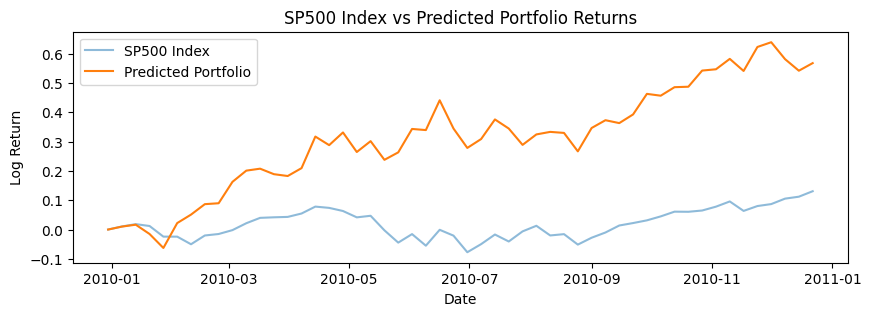

Final accumulated return of SP500 Index: 0.13084380194114686
Final accumulated return of Predicted Portfolio: 0.5681609508761555


In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 3))
plt.plot(ret_idx.cumsum(), label="SP500 Index", alpha=0.5)
plt.plot(ret_p.cumsum(), label="Predicted Portfolio")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.title("SP500 Index vs Predicted Portfolio Returns")
plt.legend()
plt.show()

print(f"Final accumulated return of SP500 Index: {ret_idx.cumsum().iloc[-1, 0]}")
print(f"Final accumulated return of Predicted Portfolio: {ret_p.cumsum().iloc[-1]}")


### Using `XGBoost`

Train model

In [121]:
from xgboost import XGBClassifier

X = train_df.iloc[:, :-1]
y = train_df["target"]

model_xgbc = XGBClassifier(
    n_estimators=100, max_depth=4, learning_rate=1.0, objective="binary:logistic", random_state=42
)
model_xgbc.fit(X, y)

print(f"Accuracy: {model_xgbc.score(X, y)}")


Accuracy: 0.6492382922700771


Predict probabilities of out- or underperform for the next week (class 1 or 0).

In [122]:
# Predict probabilities of out- or underperform for the next week (class 1 or 0).
proba_next_test = model_xgbc.predict_proba(predict_df.iloc[:, 1:])
# Create a DataFrame with the results, add tickers and sort descending.
df = pd.DataFrame(proba_next_test, columns=["P(y=0)", "P(y=1)"])
df["ticker"] = predict_df["ticker"].values
df.set_index("ticker", inplace=True)
df.sort_values(by="P(y=1)", ascending=False, inplace=True)
# Select those with a probability greater than 'th'.
th = 0.9
df_top_n = df[df["P(y=1)"] > th]
# Create a portfolio using probabilities as weights.
portfolio_weights = df_top_n.loc[:, ["P(y=1)"]] / df_top_n.loc[:, ["P(y=1)"]].sum()
portfolio_weights.columns = ["weight"]
portfolio_weights


,weight
ticker,
RSG,0.333898
UAL,0.333277
GIS,0.332825


In [123]:
# Log returns for components and index.
ret_comp = np.log(test_px_comp).diff().fillna(0)
ret_idx = np.log(test_px_idx).diff().fillna(0)
# Log returns for the portfolio.
print(f"Shape of portfolio weights: {portfolio_weights['weight'].shape}")
print(f"Shape of component returns: {ret_comp.loc[:, portfolio_weights.index].shape}")
ret_p = ret_comp.loc[:, portfolio_weights.index] @ portfolio_weights["weight"]  # R @ w
ret_p.name = "Portfolio"
ret_p

Shape of portfolio weights: (3,)
Shape of component returns: (52, 3)


Date
2009-12-30    0.000000
2010-01-06    0.011292
2010-01-13    0.027455
2010-01-20   -0.021922
2010-01-27   -0.033103
2010-02-03    0.005298
2010-02-10    0.030495
2010-02-17    0.029090
2010-02-24    0.015980
2010-03-03    0.069215
2010-03-10    0.003939
2010-03-17    0.014440
2010-03-24   -0.002658
2010-03-31   -0.003067
2010-04-07   -0.005998
2010-04-14    0.065888
2010-04-21   -0.011759
2010-04-28   -0.003714
2010-05-05   -0.019480
2010-05-12    0.018711
2010-05-19   -0.036457
2010-05-26   -0.010985
2010-06-02    0.065742
2010-06-09   -0.004582
2010-06-16    0.064666
2010-06-23   -0.040089
2010-06-30   -0.051517
2010-07-07    0.004491
2010-07-14    0.045728
2010-07-21   -0.018174
2010-07-28    0.044080
2010-08-04   -0.021811
2010-08-11   -0.058761
2010-08-18    0.022813
2010-08-25   -0.037760
2010-09-01    0.054492
2010-09-08    0.002553
2010-09-15    0.005445
2010-09-22    0.018159
2010-09-29    0.006984
2010-10-06    0.036217
2010-10-13    0.030897
2010-10-20   -0.007876
2010-1

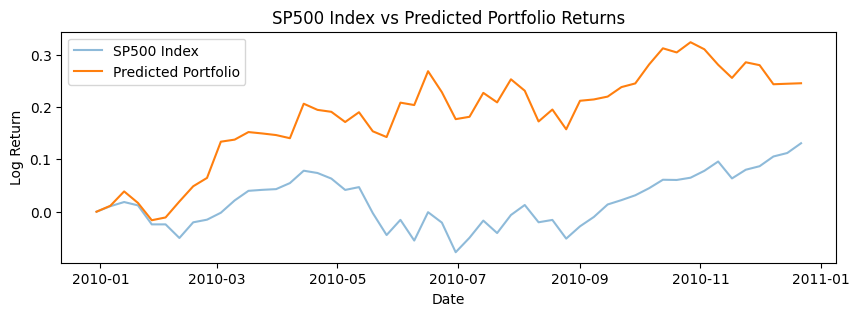

Final accumulated return of SP500 Index: 0.13084380194114686
Final accumulated return of Predicted Portfolio: 0.24547143569760027


In [124]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 3))
plt.plot(ret_idx.cumsum(), label="SP500 Index", alpha=0.5)
plt.plot(ret_p.cumsum(), label="Predicted Portfolio")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.title("SP500 Index vs Predicted Portfolio Returns")
plt.legend()
plt.show()

print(f"Final accumulated return of SP500 Index: {ret_idx.cumsum().iloc[-1, 0]}")
print(f"Final accumulated return of Predicted Portfolio: {ret_p.cumsum().iloc[-1]}")
